### AdaBoost Classifier on Income Dataset

This section will demonstrate how to build and fine-tune an AdaBoost classifier to predict income categories from the `income.csv` dataset.

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

#### 1. Load and Preprocess the Dataset

First, we'll load the `income.csv` file into a pandas DataFrame. We'll then preprocess the data by encoding categorical features and the target variable into numerical formats. Many datasets like `income.csv` are missing column headers, in which case `header=None` is needed. Otherwise, if it has a header, remove `header=None`.

In [ ]:
# Load the dataset
try:
    # Assuming the first row is a header, if not, set header=None and define columns manually
    df = pd.read_csv('/content/income.csv')
except Exception as e:
    print(f"Could not load with header, trying without: {e}")
    # If loading with header fails, try without header and assign column names
    # Common column names for an 'income' dataset (adjust if your file is different)
    column_names = [
        'age', 'workclass', 'fnlwgt', 'education', 'education-num',
        'marital-status', 'occupation', 'relationship', 'race', 'sex',
        'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
    ]
    df = pd.read_csv('/content/income.csv', header=None, names=column_names)



# Display the first few rows and info to understand the data
print("Dataset Head:")
display(df.head())
print("\nDataset Info:")
df.info()

# Identify categorical and numerical features
# Stripping whitespace from column names and string values
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

categorical_features = df.select_dtypes(include='object').columns.tolist()
# Exclude the target variable from features if it's in categorical_features
if 'income' in categorical_features:
    categorical_features.remove('income')

# Handle missing values (replace '?' with NaN and then fill or drop)
df = df.replace('?', pd.NA)

# For simplicity, we'll fill NA with the mode for categorical and mean for numerical.
# In a real scenario, more sophisticated imputation might be needed.
for col in df.columns:
    if df[col].isna().any():
        if col in categorical_features or col == 'income':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].mean())


# Encode categorical features
X = df.drop('income_level', axis=1)
y = df['income_level']

# Apply One-Hot Encoding to categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Encode the target variable 'income' (e.g., <=50K as 0, >50K as 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Dataset Head:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_level
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   fnlwgt          48842 non-null  int64
 2   education_num   48842 non-null  int64
 3   capital_gain    48842 non-null  int64
 4   capital_loss    48842 non-null  int64
 5   hours_per_week  48842 non-null  int64
 6   income_level    48842 non-null  int64
dtypes: int64(7)
memory usage: 2.6 MB

Shape of X_train: (34189, 6)
Shape of X_test: (14653, 6)


#### 2. Build and Evaluate AdaBoost Classifier with `n_estimators=10`

We'll initialize an AdaBoost Classifier with 10 estimators (decision stumps by default) and evaluate its prediction accuracy on the test set.

In [ ]:
# Initialize AdaBoost Classifier with n_estimators=10
# The base estimator is a DecisionTreeClassifier with max_depth=1 (decision stump) by default
adaboost_clf_10 = AdaBoostClassifier(n_estimators=10, random_state=42)

# Train the model
adaboost_clf_10.fit(X_train, y_train)

# Make predictions on the test set
y_pred_10 = adaboost_clf_10.predict(X_test)

# Measure the prediction score (accuracy)
score_10 = accuracy_score(y_test, y_pred_10)
print(f"Prediction score with n_estimators=10: {score_10:.4f}")

Prediction score with n_estimators=10: 0.8277


#### 3. Fine-tune AdaBoost Classifier for Best Score

Now, we'll iterate through a range of `n_estimators` values to find the number of trees that yields the best prediction score.

In [ ]:
best_score = 0
best_n_estimators = 0

# Define a range for n_estimators to test
n_estimators_range = range(1, 201, 10) # From 50 to 200 with step of 10

print("Fine-tuning AdaBoost Classifier...")
for n_est in n_estimators_range:
    adaboost_clf = AdaBoostClassifier(n_estimators=n_est, random_state=42)
    adaboost_clf.fit(X_train, y_train)
    y_pred = adaboost_clf.predict(X_test)
    current_score = accuracy_score(y_test, y_pred)

    if current_score > best_score:
        best_score = current_score
        best_n_estimators = n_est

    print(f"n_estimators = {n_est}, Score = {current_score:.4f}")

print(f"\nBest prediction score achieved: {best_score:.4f}")
print(f"With n_estimators: {best_n_estimators}")

Fine-tuning AdaBoost Classifier...
n_estimators = 1, Score = 0.8007
n_estimators = 11, Score = 0.8240
n_estimators = 21, Score = 0.8248
n_estimators = 31, Score = 0.8295
n_estimators = 41, Score = 0.8301
n_estimators = 51, Score = 0.8292
n_estimators = 61, Score = 0.8297
n_estimators = 71, Score = 0.8303
n_estimators = 81, Score = 0.8307
n_estimators = 91, Score = 0.8305
n_estimators = 101, Score = 0.8307
n_estimators = 111, Score = 0.8308
n_estimators = 121, Score = 0.8308
n_estimators = 131, Score = 0.8308
n_estimators = 141, Score = 0.8308
n_estimators = 151, Score = 0.8310
n_estimators = 161, Score = 0.8312
n_estimators = 171, Score = 0.8312
n_estimators = 181, Score = 0.8312
n_estimators = 191, Score = 0.8312

Best prediction score achieved: 0.8312
With n_estimators: 161


#### 1. Load the Iris Dataset and Select Features

First, we'll load the `iris2.csv` dataset and select only the 'petal_length' and 'petal_width' features for clustering, as requested.

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the dataset
# The iris2.csv file likely contains a header, so we remove header=None and names.
iris_df = pd.read_csv('/content/iris2.csv')

# Select features for clustering
X_iris = iris_df[['petal_length', 'petal_width']]

print("First 5 rows of selected features:")
display(X_iris.head())

First 5 rows of selected features:


,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


#### 2. Preprocessing: Scaling the Features

K-Means clustering relies on distance calculations. Features with larger values might disproportionately influence the distance. Scaling ensures that all features contribute equally to the distance metric. We will use `StandardScaler` to transform the data.

In [12]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X_iris)

print("First 5 rows of scaled features:")
display(pd.DataFrame(X_scaled, columns=X_iris.columns).head())

First 5 rows of scaled features:


,petal_length,petal_width
0,-1.341272,-1.312977
1,-1.341272,-1.312977
2,-1.398138,-1.312977
3,-1.284407,-1.312977
4,-1.341272,-1.312977


#### 3. Determine Optimal K using the Elbow Method

The Elbow Method helps in finding the optimal number of clusters (k). It involves plotting the within-cluster sum of squares (WCSS) against different values of k. The 'elbow' point in the graph indicates the optimal k.

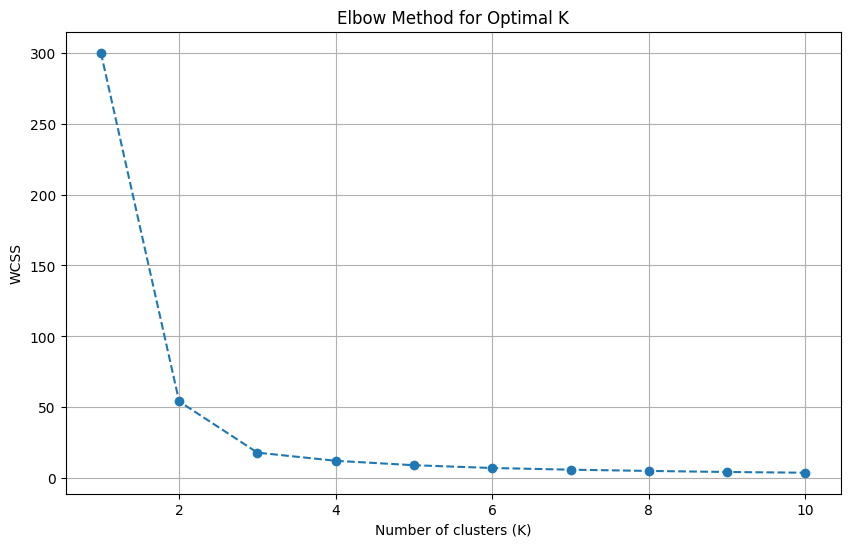

In [13]:
wcss = []
# Test k from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Based on the elbow plot above, the optimal value for 'k' appears to be **3**, as this is where the rate of decrease in WCSS significantly slows down.

#### 4. Build K-Means Clustering Model with Optimal K

Now, we will train the K-Means model using the optimal 'k' value found from the elbow method and visualize the clusters.

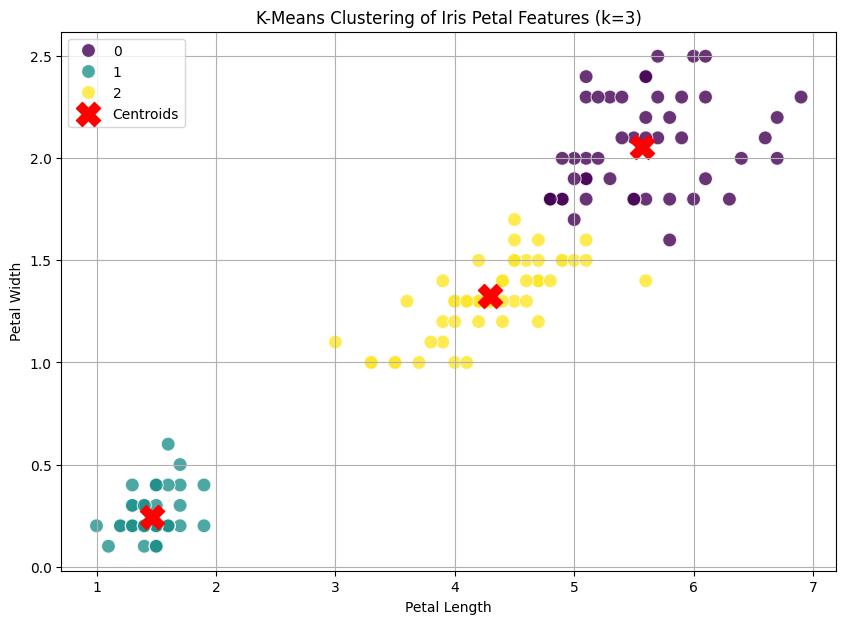

In [17]:
# Initialize K-Means with the optimal k (3)
import seaborn as sns
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', max_iter=300, n_init=10, random_state=42)

# Fit the model and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster assignments to the original (unscaled) DataFrame for visualization
iris_df['cluster'] = clusters

# Inverse transform the centroids to plot them on the original scale
original_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal_length', y='petal_width', hue='cluster', data=iris_df,
    palette='viridis', s=100, alpha=0.8, legend='full'
)
plt.scatter(original_centroids[:, 0], original_centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'K-Means Clustering of Iris Petal Features (k={k_optimal})')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.grid(True)
plt.show()